# Gradient Boosting Regressor (GBR)

Author: Pete King

We test the performance of an ensemble decision tree based on the concept of gradient boosting, where many weak learners are combined to provide predictions that are less likely to overfit to training data.  Compared to time series methods like ARIMA, this model assumes no relationship between observations at different timestamps.  In our case, we examine how well such a model can predict future volatility for an ETF over a moderate horizon (63 business days or one quarter), given a feature vector of market, macroeconomic, and other financial variables.

Specifically, each observation is a feature vector (x_t) that contains the daily return for the ETF, its near-term historic volatility, and other features at time t (a daily observation).  The label (y_t) is the mid-term future volatility (63 business day outlook), which we computed earlier using a rolling window.

Unlike other classic machine learning estimators, the GBR estimator works as a decision tree and does not require us to standardize our input features.

In [1]:
#123456789012345678901234567890123456789012345678901234567890123456789012345678
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    make_scorer,
    r2_score,
    mean_absolute_error
)
from sklearn.model_selection import (
    TimeSeriesSplit,
    GridSearchCV
)
from sklearn.ensemble import GradientBoostingRegressor

import data_prep as dp

DATA_FOLDER = 'data/train-val-test/'
TRAIN_DATA_FILE = DATA_FOLDER + 'train_etf_data.csv'
VAL_DATA_FILE = DATA_FOLDER + 'val_etf_data.csv'
TICKER = 'SPY'

## I. Import data

We have already split our data into training and validation sets.  We reserve the held-out validation set (val_df) to plot predictions for comparisons against other models, but we further divide the training set into cross-validation folds to take advantage of scikit-learn's [TimeSeriesSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html) function.  This gives us an easy way to apply scikit-learn's standard cross-validation (CV) methods for hyperparameter optimization while preserving chronological order between training and validation subsets within CV folds.

In [2]:
train_df = pd.read_csv(
    TRAIN_DATA_FILE,
    index_col='date',
    parse_dates=True
)
val_df = pd.read_csv(
    VAL_DATA_FILE,
    index_col='date',
    parse_dates=True
)
data_cols = train_df.drop(columns=[TICKER + '_f-vol_target']).columns
label_col = [TICKER + '_f-vol_target']

In [3]:
# Separate features from labels
X = train_df.dropna()[data_cols].astype(np.float32).values 
y = train_df.dropna()[label_col].astype(np.float32).values.reshape(-1,)
# Define time series cross-validation split
ts_cv = TimeSeriesSplit(
    n_splits=3,
    test_size=252,
    gap=63
)

In [4]:
# Define model, metrics, and Grid Search for hyperparameter tuning
estimator = GradientBoostingRegressor(loss='absolute_error')
metrics = {
    'MAE': make_scorer(mean_absolute_error)
}
params = {
    'max_depth': [2, 3, 3, 5, 10],
}
reg = GridSearchCV(
    estimator,
    params,
    scoring=metrics,
    n_jobs=-1,
    refit='MAE',
    cv=ts_cv
)

In [ ]:
reg.fit(X, y)
# estimator.fit(X, y)

In [6]:
X_val = val_df.dropna()[data_cols].astype(np.float32).values 
y_val = val_df.dropna()[label_col].astype(np.float32).values.reshape(-1,)

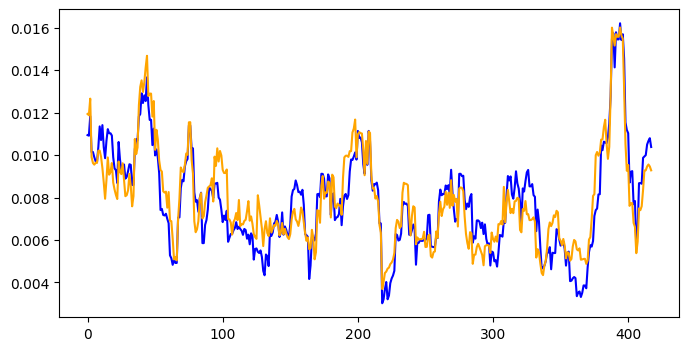

In [7]:
preds = reg.predict(X_val)
x = range(len(y_val))

fig = plt.figure(figsize=(8, 4))
ax = fig.subplots()

ax.plot(x, y_val, color='blue')
ax.plot(x, preds, color='orange')

In [8]:
reg.score(X_val, y_val)

0.000847428715715528